# ML - K-MEANS

In [37]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import geopandas as gpd
import contextily as ctx
import pickle

# Paso 1: Carga del conjunto de datos

In [4]:
df = pd.read_csv('../data/raw/housing.csv')
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [5]:
df = df.drop(['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal'], axis=1)
X=df
X

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25
...,...,...,...
20635,1.5603,39.48,-121.09
20636,2.5568,39.49,-121.21
20637,1.7000,39.43,-121.22
20638,1.8672,39.43,-121.32


In [6]:
# Escalamos las 3 variables
robust_scaler = RobustScaler()

robust_scaler_train = robust_scaler.fit_transform(X)

X_robust_scaler = pd.DataFrame(robust_scaler_train,
                               columns=X.columns,
                               index=X.index)

X_robust_scaler

,MedInc,Latitude,Longitude
0,2.197582,0.957672,-0.986807
1,2.186664,0.952381,-0.984169
2,1.707732,0.949735,-0.989446
3,0.967177,0.949735,-0.992084
4,0.142854,0.949735,-0.992084
...,...,...,...
20635,-0.905796,1.380952,-0.686016
20636,-0.448655,1.383598,-0.717678
20637,-0.841709,1.367725,-0.720317
20638,-0.765007,1.367725,-0.746702


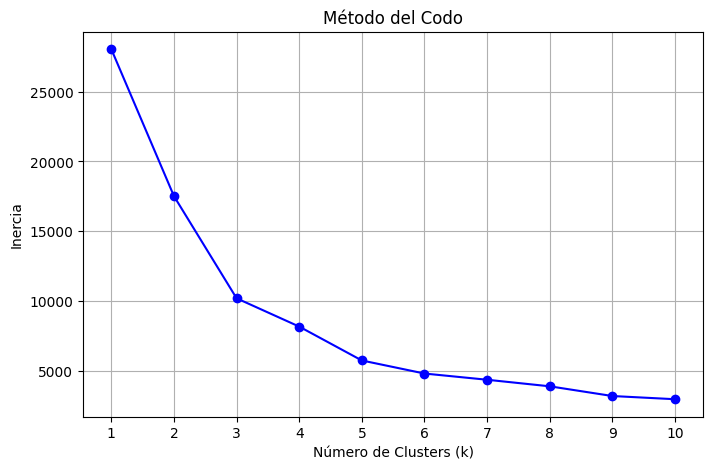

In [ ]:
# Lista para guardar la inercia de cada K
inertias = []
K_range = range(1, 11)

# Probamos diferentes valores de k
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_robust_scaler)
    inertias.append(kmeans.inertia_)

# Graficamos la curva del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.xticks(K_range)
plt.grid(True)

> ## Conclusiones:
>
> - Podemos observar en el gráfico que los mejores valores de k son 5 y 6 ya que a partir de ahi se empieza a aplanar la curva
> - Vamos a probar el modelo con k=6

# Paso 2: Construimos un K-Means y visualizamos los datos

In [9]:
# Entrenamos el modelo con k=6
km_model = KMeans(n_clusters = 6, random_state = 21)
df['cluster'] = km_model.fit_predict(X)
df

,MedInc,Latitude,Longitude,cluster
0,8.3252,37.88,-122.23,0
1,8.3014,37.86,-122.22,0
2,7.2574,37.85,-122.24,0
3,5.6431,37.85,-122.25,0
4,3.8462,37.85,-122.25,3
...,...,...,...,...
20635,1.5603,39.48,-121.09,3
20636,2.5568,39.49,-121.21,3
20637,1.7000,39.43,-121.22,3
20638,1.8672,39.43,-121.32,3


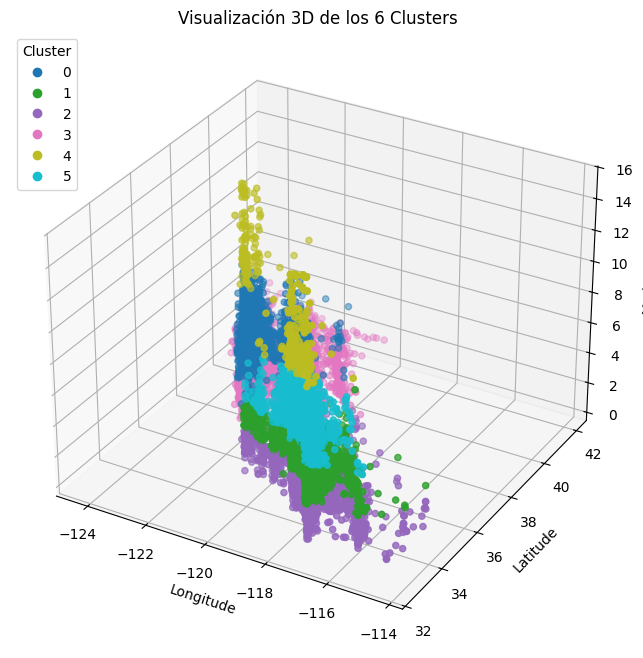

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

x = df['Longitude']
y = df['Latitude']
z = df['MedInc']
c = df['cluster']

scatter = ax.scatter(x, y, z, c=c, cmap='tab10')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('MedInc')
ax.set_title('Visualización 3D de los 6 Clusters')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc='upper left')

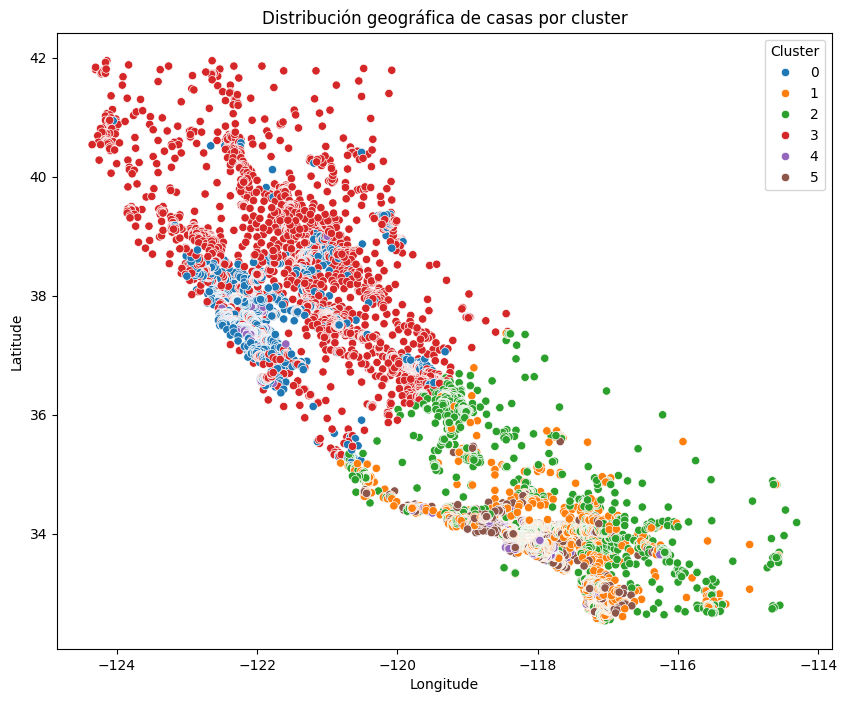

In [46]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df,
                x='Longitude',
                y='Latitude',
                hue='cluster',
                palette='tab10')
plt.title('Distribución geográfica de casas por cluster')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')

(np.float64(-13898461.064521791),
 np.float64(-12669048.60820088),
 np.float64(3768450.223789852),
 np.float64(5219447.026721441))

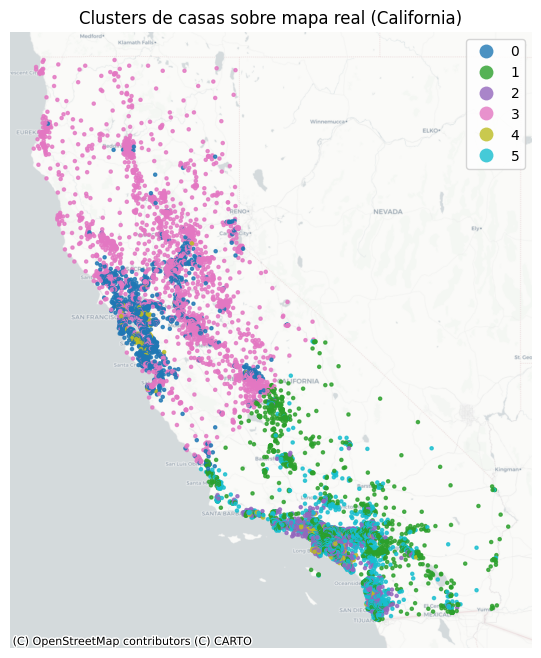

In [27]:
# Creamos GeoDataFrame con las coordenadas
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs='EPSG:4326')

# Convertimos a proyección métrica para agregar fondo de mapa
gdf = gdf.to_crs(epsg=3857)

# Graficamos por cluster
ax = gdf.plot(figsize=(10, 8),
              column='cluster',
              categorical=True,
              legend=True,
              cmap='tab10',
              markersize=5,
              alpha=0.8)

# Agregamos fondo de mapa 
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

plt.title("Clusters de casas sobre mapa real (California)")
plt.axis('off')

/tmp/ipykernel_590/3367748424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='cluster',palette='tab10')


Text(0, 0.5, 'Grupos de bloques censales')

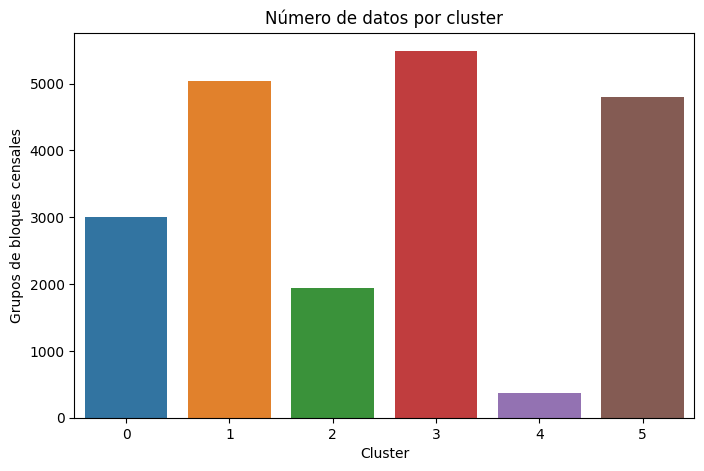

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='cluster',palette='tab10')
plt.title('Número de datos por cluster')
plt.xlabel('Cluster')
plt.ylabel('Grupos de bloques censales')

In [13]:
# Calculamos el ingreso medio de cada cluster
ingreso_medio_por_cluster = df.groupby('cluster')['MedInc'].mean().sort_index()
ingreso_medio_por_cluster

cluster
0     5.406978
1     2.353209
2     6.492118
3     2.745477
4    11.457929
5     4.136246
Name: MedInc, dtype: float64

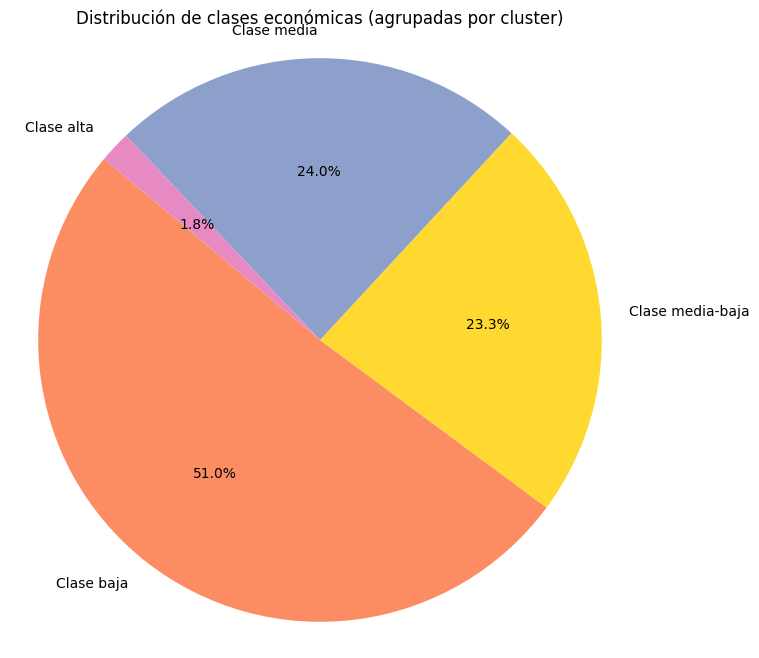

In [ ]:
# Mapeo de cada cluster a clase económica
cluster_to_class = {0: 'Clase media',
                    1: 'Clase baja',
                    2: 'Clase media',
                    3: 'Clase baja',
                    4: 'Clase alta',
                    5: 'Clase media-baja'}

# Creamos nueva columna con la clase económica
df['clase'] = df['cluster'].map(cluster_to_class)

# Contamos cuántas muestras hay en cada clase
clase_counts = df['clase'].value_counts()

# Ordenamos si deseas una secuencia específica
clase_counts = clase_counts[['Clase baja', 'Clase media-baja', 'Clase media', 'Clase alta']]

# Colores personalizados
colors = ['#fc8d62', '#ffd92f', '#8da0cb', '#e78ac3']

# Graficamos el pie chart
plt.figure(figsize=(8, 8))
plt.pie(clase_counts, labels=clase_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Distribución de clases económicas (agrupadas por cluster)')
plt.axis('equal')  # Para mantener el círculo

(np.float64(-13898461.064521791),
 np.float64(-12669048.60820088),
 np.float64(3768450.223789852),
 np.float64(5219447.026721441))

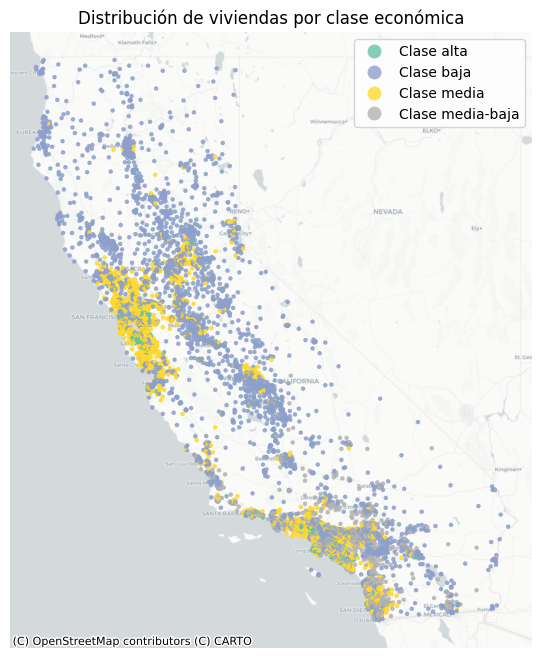

In [26]:
# Creamos GeoDataFrame las coordenadas
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs='EPSG:4326')

# Convertimos a proyección métrica (necesaria para usar contextily)
gdf = gdf.to_crs(epsg=3857)

# Mapa por clase económica
ax = gdf.plot(figsize=(10, 8),
              column='clase',
              categorical=True,
              legend=True,
              cmap='Set2',  
              markersize=5,
              alpha=0.8)

# Agregamos fondo de mapa
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Personalización
plt.title("Distribución de viviendas por clase económica")
plt.axis('off')

> ## Observaciones:
>
> - Observamos que ha clasificado los clusters con una tendencia geométrica, pero hay datos que no la siguen ya que también tiene en cuenta el promedio de ingresos
> - Los cluster 1, 3 y 5 es el que mayor grupo de bloques tiene y es donde hay menor promedio de ingresos:
>  1. Practicamente la mitad del estado de California (51%) es de clase baja (1 y 3)
>  2. Casi un cuarto del estado de California (23,3%) es de clase media-baja (5)
> - Con más promedio de ingresos les sigue los cluster 0 y 2 que corresponden a la clase media, con un 24%
> - El cluster 4 es con diferencia el que menor grupo de bloques tiene y donde hay mayor promedio de ingresos, esto significa que hay una pequeña parte del estado de California que es de clase económica alta, solo un 1.8%
> - La mayoría de grupos de bloques de clase media y alta están en la costa
> - La mayoría de grupos de bloques de clase baja y media-baja están en interior

# Paso 3: Entrena un modelo de clasificación supervisada

In [33]:
X = df.drop(['cluster', 'clase'], axis=1)
y = df['cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)
X_test


,MedInc,Latitude,Longitude
18726,1.6033,40.58,-122.30
1046,2.5250,38.38,-120.72
15508,4.2357,33.14,-117.08
828,5.6400,37.62,-122.08
19007,2.4330,38.36,-121.98
...,...,...,...
17027,6.1004,37.51,-122.29
19373,3.7031,37.81,-120.90
6129,3.5625,34.08,-117.99
5466,3.0150,33.99,-118.47


In [34]:
rf_model = RandomForestClassifier(random_state=21)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=21)

In [35]:
y_pred = rf_model.predict(X_test)

In [36]:
accuracy_score(y_test, y_pred)

0.9927325581395349

In [40]:
with open('../models/09-rf-model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('../models/09-km-model.pkl', 'wb') as f:
    pickle.dump(km_model, f)

> ## Conclusiones:
>
> - Con `RandomForestClassifier` hemos obtenido un accuracy casi perfecto del 0,993% dificilmente mejorable, por lo que no lo vamos a optimizar ya que decidimos que es el mejor modelo